# Model Analysis

## Import Library

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

2026-02-28 17:16:35.904699: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-28 17:16:35.945162: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 17:16:37.052582: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df_train = pd.read_csv('../split/train.csv')
df_train.head()

,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps,Target
0,71.0,78.0,37.5,-489.0,0.731082,2.682259,0
1,40.0,73.0,32.8,-259.0,0.351941,0.029813,1
2,41.0,75.0,35.5,-203.0,2.902251,6.970937,1
3,41.0,76.0,36.3,-356.0,0.056415,0.051308,0
4,64.0,72.0,34.1,-280.0,6.253602,167.592770,2


In [3]:
X_test = df_train.drop("Target", axis=1)
y_test = df_train["Target"]

## Mode Evaluation

In [9]:
def evaluate_model(model):
    class_name = ['High Load', 'Normal Usage', 'Network Intensive']

    y_prob = model.predict(X_test)
    y_predict = np.argmax(y_prob, axis=1)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_predict, target_names=class_name))

    cm = confusion_matrix(y_test, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix - ANN")
    plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Classification Report

                   precision    recall  f1-score   support

        High Load       0.98      0.96      0.97       413
     Normal Usage       0.95      0.99      0.97       641
Network Intensive       0.98      0.94      0.96       323

         accuracy                           0.97      1377
        macro avg       0.97      0.96      0.97      1377
     weighted avg       0.97      0.97      0.97      1377



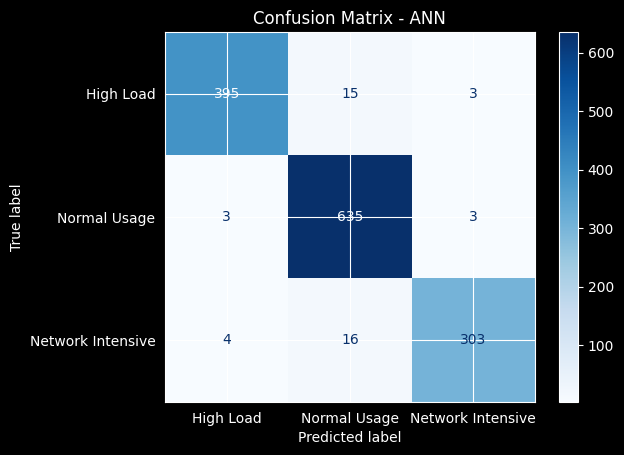

In [10]:
model = tf.keras.models.load_model('../model/model.keras')
evaluate_model(model)